# **Flight Cancellation Predictor ✈**

In [ ]:
# install packages
import pandas as pd
import numpy as np
import holidays
import os
import sys
from datetime import timedelta

# autogluon
from autogluon.tabular import TabularPredictor

# visuals
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv

# evaluation metrics
import evaluate

# display settings
pd.options.display.width = None
pd.set_option('display.max_colwidth', None) # 100
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking

# **Import Data**

In [ ]:
# # Get files from GitHub
# # https://www.transtats.bts.gov/DatabaseInfo.asp?QO_VQ=EFD%20&Yv0x=D
# # Dictionary : https://www.transtats.bts.gov/Fields.asp?gnoyr_VQ=FGJ
# # Get parquet files
url_A = "T_ONTIME_REPORTING11_A.parquet"
url_B = "T_ONTIME_REPORTING11_B.parquet"

df_A = pd.read_parquet(url_A)
df_B = pd.read_parquet(url_B)

# stack
df = pd.concat([df_A, df_B], ignore_index=True)




# Add in National Plan of Integrated Airport Systems (NPIAS) data : https://www.faa.gov/airports/planning_capacity/npias/current
# Dictionary : https://www.faa.gov/sites/faa.gov/files/airports/planning_capacity/npias/current/ARP-NPIAS-2025-2029-Appendix-A.pdf
# # Get Excel files
url = "ARP-NPIAS-2025-2029-AppendixA.xlsx"
arp = pd.read_excel(url)

# join
df = pd.merge(df,arp, how='left',left_on='ORIGIN',right_on='LocID')

df.columns = df.columns.str.lower()
df2 = df.copy()
df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_airline_id,op_carrier,tail_num,op_carrier_fl_num,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin,origin_city_name,origin_state_abr,origin_state_fips,origin_state_nm,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest,dest_city_name,dest_state_abr,dest_state_fips,dest_state_nm,dest_wac,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,dep_delay_group,dep_time_blk,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,arr_delay_group,arr_time_blk,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,first_dep_time,total_add_gtime,longest_add_gtime,div_airport_landings,div_reached_dest,div_actual_elapsed_time,div_arr_delay,div_distance,div1_airport,div1_airport_id,div1_airport_seq_id,div1_wheels_on,div1_total_gtime,div1_longest_gtime,div1_wheels_off,div1_tail_num,div2_airport,div2_airport_id,div2_airport_seq_id,div2_wheels_on,div2_total_gtime,div2_longest_gtime,div2_wheels_off,div2_tail_num,div3_airport,div3_airport_id,div3_airport_seq_id,div3_wheels_on,div3_total_gtime,div3_longest_gtime,div3_wheels_off,div3_tail_num,div4_airport,div4_airport_id,div4_airport_seq_id,div4_wheels_on,div4_total_gtime,div4_longest_gtime,div4_wheels_off,div4_tail_num,div5_airport,div5_airport_id,div5_airport_seq_id,div5_wheels_on,div5_total_gtime,div5_longest_gtime,div5_wheels_off,div5_tail_num,state,city,airport,locid,owner-\nship,svc lvl\n(fy25),hub\n(fy25),role\n(fy25),enplaned\n(cy23/fy25),based aircraft\n(fy25),development\nestimate\n2025-2029
0,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,4941,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,1700,1649.0,-11.0,0.0,0.0,-1.0,1700-1759,22.0,1711.0,1808.0,2.0,1843,1810.0,-33.0,0.0,0.0,-2.0,1800-1859,0.0,None,0.0,163.0,141.0,117.0,1.0,745.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York,New York,John F Kennedy International,JFK,PU,P,L,NaN,30804261.0,0.0,257289334.0
1,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,4969,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,1235,1230.0,-5.0,0.0,0.0,-1.0,1200-1259,8.0,1238.0,1526.0,11.0,1605,1537.0,-28.0,0.0,0.0,-2.0,1600-1659,0.0,None,0.0,150.0,127.0,108.0,1.0,745.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wisconsin,Milwaukee,General Mitchell International,MKE,PU,P,M,NaN,2959810.0,83.0,131799951.0
2,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5264,10990,1099005,30990,CHO,"Charlottesville, VA",VA,51,Virginia,38,12953,1295304,31703,LGA,"New York, NY",NY,36,New York,22,745,740.0,-5.0,0.0,0.0,-1.0,0700-0759,10.0,750.0,841.0,8.0,915,849.0,-26.0,0.0,0.0,-2.0,0900-0959,0.0,None,0.0,90.0,69.0,51.0,1.0,305.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Virginia,Charlottesville-Albemarle Airport,Charlottesville-Albemarle,CHO,PU,P,N,NaN,308462.0,62.0,6105340.0
3,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5315,12953,1295304,31703,LGA,"New York, NY",NY,36,New York,22,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,1018,1007.0,-11.0,0.0,0.0,-1.0,1000-1059,37.0,1044.0,1131.0,4.0,1155,1135.0,-20.0,0.0,0.0,-2.0,1100-1159,0.0,None,0.0,157.0,148.0,107.0,1.0,738.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611132 entries, 0 to 611131
Columns: 120 entries, year to development
estimate
2025-2029
dtypes: float64(72), int64(21), object(27)
memory usage: 559.5+ MB


In [ ]:
df.describe()

,year,quarter,month,day_of_month,day_of_week,op_carrier_airline_id,op_carrier_fl_num,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin_state_fips,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest_state_fips,dest_wac,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,dep_delay_group,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,arr_delay_group,cancelled,diverted,crs_elapsed_time,actual_elapsed_time,air_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,first_dep_time,total_add_gtime,longest_add_gtime,div_airport_landings,div_reached_dest,div_actual_elapsed_time,div_arr_delay,div_distance,div1_airport_id,div1_airport_seq_id,div1_wheels_on,div1_total_gtime,div1_longest_gtime,div1_wheels_off,div2_airport_id,div2_airport_seq_id,div2_wheels_on,div2_total_gtime,div2_longest_gtime,div2_wheels_off,div3_airport,div3_airport_id,div3_airport_seq_id,div3_wheels_on,div3_total_gtime,div3_longest_gtime,div3_wheels_off,div3_tail_num,div4_airport,div4_airport_id,div4_airport_seq_id,div4_wheels_on,div4_total_gtime,div4_longest_gtime,div4_wheels_off,div4_tail_num,div5_airport,div5_airport_id,div5_airport_seq_id,div5_wheels_on,div5_total_gtime,div5_longest_gtime,div5_wheels_off,div5_tail_num,enplaned\n(cy23/fy25),based aircraft\n(fy25),development\nestimate\n2025-2029
count,611132.0,611132.0,611132.0,611132.000000,611132.000000,611132.000000,611132.000000,611132.000000,6.111320e+05,611132.000000,611132.000000,611132.000000,611132.000000,6.111320e+05,611132.000000,611132.000000,611132.000000,611132.000000,603699.000000,603676.000000,603676.000000,603676.000000,603676.000000,603289.000000,603289.000000,603138.000000,603138.000000,611132.000000,603138.000000,601272.000000,601272.000000,601272.000000,601272.000000,611132.000000,611132.000000,611132.000000,601272.000000,601272.000000,611132.0,611132.000000,611132.000000,149945.000000,149945.000000,149945.000000,149945.000000,149945.000000,4968.000000,4968.000000,4968.000000,611132.000000,1984.000000,1866.000000,1866.000000,1984.000000,2017.000000,2.017000e+03,2017.000000,2017.000000,2017.000000,1871.000000,12.000000,1.200000e+01,12.000000,12.000000,12.000000,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.095350e+05,609535.000000,6.095350e+05
mean,2024.0,2.0,6.0,15.567190,4.147340,19947.986186,2531.827586,12635.064299,1.263510e+06,31727.186294,27.262403,54.585926,12635.101899,1.263514e+06,31727.248387,27.262842,54.584921,1338.170986,1340.887033,16.945726,19.730652,0.253306,0.423553,17.813090,1360.829534,1439.982407,8.594882,1481.902587,1441.366049,11.807215,19.385967,0.249380,0.161661,0.012888,0.003246,146.584314,141.486708,115.098789,1.0,843.917101,3.848241,25.287285,4.441328,13.090560,0.128607,30.505445,1406.769324,44.612319,43.465177,0.003750,0.940524,427.905681,286.915863,11.519657,12767.754090,1.276779e+06,1555.172533,44.352504,35.398612,1552.909674,12516.333333,1.251637e+06,922.333333,25.333333,19.750000,1434.714286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.834863e+07,68.839617,6.761122e+08
std,0.0,0.0,0.0,8.605649,2.037139,371.470598,1650.672836,1534.864432,1.534863e+05,1328.902452,16.724107,26.645445,1534.857077,1.534855e+05,1328.926359,16.724265,26.646078,503.949015,525.937857,61.601688,60.597247,0.434905,2.585806,9.735525,530.289292,565.774273,7.404388,537.426473,572.020987,63.187529,60.144475,0.432654,2.724454,0.112790,0.056885,72.176277,72.544502,70.382880,0.0,603.182942,2.365091,77.336344,33.005392,33.709895,3.839828,62.957475,504.202221,41.204683,38.425819,0.087523,0.236573,229.150221,251.595741,97.277994,1572.098365,1.572097e+05,573.955567,38.005132,34.522246,622.088789,1653.926696,1.653927e+05,863.532421,21.133056,17.720686,433.916549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [ ]:
df['cancelled'].value_counts(normalize=True)

,proportion
cancelled,
0.0,0.987112
1.0,0.012888


In [ ]:
df['cancelled'].value_counts()

,count
cancelled,
0.0,603256
1.0,7876


In [ ]:
df.dtypes

,0
year,int64
quarter,int64
month,int64
day_of_month,int64
day_of_week,int64
fl_date,object
op_unique_carrier,object
op_carrier_airline_id,int64
op_carrier,object
tail_num,object


In [ ]:
# change dtypes
df['cancelled'] = df['cancelled'].astype('category')
df['op_unique_carrier'] = df['op_unique_carrier'].astype('string')
df['op_carrier_airline_id'] = df['op_carrier_airline_id'].astype('string')
df['op_carrier'] = df['op_carrier'].astype('string')
df['op_carrier_fl_num'] = df['op_carrier_fl_num'].astype('string')

# if a col name starts with a given string, change dtype to string
for col in df.columns:
  if col.startswith('origin'):
    df[col] = df[col].astype('str')

for col in df.columns:
  if col.startswith('dest'):
    df[col] = df[col].astype('str')

df.dtypes

,0
year,int64
quarter,int64
month,int64
day_of_month,int64
day_of_week,int64
fl_date,object
op_unique_carrier,string[python]
op_carrier_airline_id,string[python]
op_carrier,string[python]
tail_num,object


In [ ]:
# holidays
# full list of holidays in various countries -> https://pypi.org/project/holidays/
US_holidays = holidays.US()

# preview list of reocgnized holidays for the years in our dataset
# NOTE: You might want to append other relevant holidays that are not recognized in this list that may have an effect on sales
# such as Black Friday in the US or company/industry-specific holidays (ex: Valentine's Day may be more relevant for a jeweler than an airline)
years = [2023,2024,2025]
for date in holidays.US(years=years).items():
  print(date)

# save the holidays as a separate string to compare against the df
US_Holidays = []
for date in holidays.US(years=years).items():
  US_Holidays.append(str(date[0]))

(datetime.date(2024, 1, 1), "New Year's Day")
(datetime.date(2024, 5, 27), 'Memorial Day')
(datetime.date(2024, 6, 19), 'Juneteenth National Independence Day')
(datetime.date(2024, 7, 4), 'Independence Day')
(datetime.date(2024, 9, 2), 'Labor Day')
(datetime.date(2024, 11, 11), 'Veterans Day')
(datetime.date(2024, 11, 28), 'Thanksgiving Day')
(datetime.date(2024, 12, 25), 'Christmas Day')
(datetime.date(2024, 1, 15), 'Martin Luther King Jr. Day')
(datetime.date(2024, 2, 19), "Washington's Birthday")
(datetime.date(2024, 10, 14), 'Columbus Day')
(datetime.date(2025, 1, 1), "New Year's Day")
(datetime.date(2025, 5, 26), 'Memorial Day')
(datetime.date(2025, 6, 19), 'Juneteenth National Independence Day')
(datetime.date(2025, 7, 4), 'Independence Day')
(datetime.date(2025, 9, 1), 'Labor Day')
(datetime.date(2025, 11, 11), 'Veterans Day')
(datetime.date(2025, 11, 27), 'Thanksgiving Day')
(datetime.date(2025, 12, 25), 'Christmas Day')
(datetime.date(2025, 1, 20), 'Martin Luther King Jr. Day'

In [ ]:
# create a separate date value type so we can compare to the holidays string list
df['fl_date_dt'] = pd.to_datetime(df['fl_date'])

# Check if the dates in the 'date' column are holidays
df['ind_is_holiday'] = df['fl_date_dt'].apply(lambda x: US_holidays.get(x.date()) is not None) # marks w true false

# mark date as 1 if it falls on a US holiday, zero otherwise
df['ind_is_holiday'] = np.where(df['ind_is_holiday']==True,1.0,0.0)

/tmp/ipython-input-3722549321.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fl_date_dt'] = pd.to_datetime(df['fl_date'])


In [ ]:
# Check if the dates in the 'date' column are within X days of a holiday
df['ind_is_near_holiday_down'] = df['fl_date_dt'].apply(lambda x: any((x.date() - timedelta(days=i)) in US_holidays for i in range(3)))
df['ind_is_near_holiday_up'] = df['fl_date_dt'].apply(lambda x: any((x.date() + timedelta(days=i)) in US_holidays for i in range(3)))

df['ind_is_near_holiday'] = np.where((df['ind_is_near_holiday_down'] ==True) | (df['ind_is_near_holiday_up'] ==True),1.0,0.0)

In [ ]:
# Calculate proximity to/from a holiday
def days_until_next_holiday(flight_date, holiday_calendar):

    # Sort holiday list so that the next holiday can be found
    future_holidays = sorted([d for d in holiday_calendar if d >= flight_date.date()])

    # If there is no next holiday, return None (this shouldn't happen since we included future years)
    if not future_holidays:
        return None

    # Find the next holiday date
    next_holiday = future_holidays[0]

    # Calculate days difference
    days_diff = (next_holiday - flight_date.date()).days
    return days_diff

df['days_until_holiday'] = df['fl_date_dt'].apply(lambda x: days_until_next_holiday(x, US_holidays))


def days_since_last_holiday(flight_date, holiday_calendar):

    # Sort holiday list so that the next holiday can be found
    past_holidays = sorted([d for d in holiday_calendar if d <= flight_date.date()])

    # If there is no next holiday, return None (this shouldn't happen since we included prior years)
    if not past_holidays:
        return None

    # Find the next holiday date
    last_holiday = past_holidays[0]

    # Calculate days difference
    days_diff = (flight_date.date() - last_holiday).days
    return days_diff

df['days_since_last_holiday'] = df['fl_date_dt'].apply(lambda x: days_since_last_holiday(x, US_holidays))
df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_airline_id,op_carrier,tail_num,op_carrier_fl_num,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin,origin_city_name,origin_state_abr,origin_state_fips,origin_state_nm,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest,dest_city_name,dest_state_abr,dest_state_fips,dest_state_nm,dest_wac,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,dep_delay_group,dep_time_blk,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,arr_delay_group,arr_time_blk,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,first_dep_time,total_add_gtime,longest_add_gtime,div_airport_landings,div_reached_dest,div_actual_elapsed_time,div_arr_delay,div_distance,div1_airport,div1_airport_id,div1_airport_seq_id,div1_wheels_on,div1_total_gtime,div1_longest_gtime,div1_wheels_off,div1_tail_num,div2_airport,div2_airport_id,div2_airport_seq_id,div2_wheels_on,div2_total_gtime,div2_longest_gtime,div2_wheels_off,div2_tail_num,div3_airport,div3_airport_id,div3_airport_seq_id,div3_wheels_on,div3_total_gtime,div3_longest_gtime,div3_wheels_off,div3_tail_num,div4_airport,div4_airport_id,div4_airport_seq_id,div4_wheels_on,div4_total_gtime,div4_longest_gtime,div4_wheels_off,div4_tail_num,div5_airport,div5_airport_id,div5_airport_seq_id,div5_wheels_on,div5_total_gtime,div5_longest_gtime,div5_wheels_off,div5_tail_num,state,city,airport,locid,owner-\nship,svc lvl\n(fy25),hub\n(fy25),role\n(fy25),enplaned\n(cy23/fy25),based aircraft\n(fy25),development\nestimate\n2025-2029,fl_date_dt,ind_is_holiday,ind_is_near_holiday_down,ind_is_near_holiday_up,ind_is_near_holiday,days_until_holiday,days_since_last_holiday
0,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,4941,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,1700,1649.0,-11.0,0.0,0.0,-1.0,1700-1759,22.0,1711.0,1808.0,2.0,1843,1810.0,-33.0,0.0,0.0,-2.0,1800-1859,0.0,None,0.0,163.0,141.0,117.0,1.0,745.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York,New York,John F Kennedy International,JFK,PU,P,L,NaN,30804261.0,0.0,257289334.0,2024-06-01,0.0,False,False,0.0,18,152
1,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,4969,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,1235,1230.0,-5.0,0.0,0.0,-1.0,1200-1259,8.0,1238.0,1526.0,11.0,1605,1537.0,-28.0,0.0,0.0,-2.0,1600-1659,0.0,None,0.0,150.0,127.0,108.0,1.0,745.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wisconsin,Milwaukee,General Mitchell International,MKE,PU,P,M,NaN,2959810.0,83.0,131799951.0,2024-06-01,0.0,False,False,0.0,18,152
2,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5264,10990,1099005,30990,CHO,"Charlottesville, VA",VA,51,Virginia,38,12953,1295304,31703,LGA,"New York, NY",NY,36,New York,22,745,740.0,-5.0,0.0,0.0,-1.0,0700-0759,10.0,750.0,841.0,8.0,915,849.0,-26.0,0.0,0.0,-2.0,0900-0959,0.0,None,0.0,90.0,69.0,51.0,1.0,305.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Virginia,Charlottesville-Albemarle Airport,Charlottesville-Albemarle,CHO,PU,P,N,NaN,308462.0,62.0,6105340.0,2024-06-01,0.0,False,False,0.0,18,152
3,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5315,12953,1295304,31703,LGA,"New York, NY",NY

In [ ]:
# Check for missing values, impute where necessary
df.isnull().sum()

,0
year,0
quarter,0
month,0
day_of_month,0
day_of_week,0
fl_date,0
op_unique_carrier,0
op_carrier_airline_id,0
op_carrier,0
tail_num,1516


In [ ]:
# get hour from departure and arrival times
df['scheduled_hour_of_departure'] = df['crs_dep_time'].astype(str).str.zfill(4).str.slice(0, 2).astype(int)
df['scheduled_hour_of_arrival'] = df['crs_arr_time'].astype(str).str.zfill(4).str.slice(0, 2).astype(int)

# indicator variables
df['ind_is_local'] = np.where(df['role\n(fy25)'] == 'Local', 1, 0) # maybe these airports dont have many resources to prevent cancellations if something goes wrong
df['ind_is_summer'] = np.where((df['month'] >= 6) & (df['month'] <= 8), 1, 0)
df['ind_late_scheduled_hour_of_departure'] = np.where((df['scheduled_hour_of_departure'] >= 20) & (df['scheduled_hour_of_departure'] <= 22), 1, 0)
df['ind_late_scheduled_hour_of_arrival'] = np.where((df['scheduled_hour_of_arrival'] >= 21) & (df['scheduled_hour_of_arrival'] <= 23), 1, 0)
df['ind_early_departure'] = np.where(df['dep_delay'] < 0, 1, 0)
df['ind_dest_TX_long_dist'] = np.where((df['dest_state_abr'] == 'TX') & (df['distance'] >= 1000), 1, 0)


df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_airline_id,op_carrier,tail_num,op_carrier_fl_num,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin,origin_city_name,origin_state_abr,origin_state_fips,origin_state_nm,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest,dest_city_name,dest_state_abr,dest_state_fips,dest_state_nm,dest_wac,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,dep_delay_group,dep_time_blk,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,arr_delay_group,arr_time_blk,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,first_dep_time,total_add_gtime,longest_add_gtime,div_airport_landings,div_reached_dest,div_actual_elapsed_time,div_arr_delay,div_distance,div1_airport,div1_airport_id,div1_airport_seq_id,div1_wheels_on,div1_total_gtime,div1_longest_gtime,div1_wheels_off,div1_tail_num,div2_airport,div2_airport_id,div2_airport_seq_id,div2_wheels_on,div2_total_gtime,div2_longest_gtime,div2_wheels_off,div2_tail_num,div3_airport,div3_airport_id,div3_airport_seq_id,div3_wheels_on,div3_total_gtime,div3_longest_gtime,div3_wheels_off,div3_tail_num,div4_airport,div4_airport_id,div4_airport_seq_id,div4_wheels_on,div4_total_gtime,div4_longest_gtime,div4_wheels_off,div4_tail_num,div5_airport,div5_airport_id,div5_airport_seq_id,div5_wheels_on,div5_total_gtime,div5_longest_gtime,div5_wheels_off,div5_tail_num,state,city,airport,locid,owner-\nship,svc lvl\n(fy25),hub\n(fy25),role\n(fy25),enplaned\n(cy23/fy25),based aircraft\n(fy25),development\nestimate\n2025-2029,fl_date_dt,ind_is_holiday,ind_is_near_holiday_down,ind_is_near_holiday_up,ind_is_near_holiday,days_until_holiday,days_since_last_holiday,scheduled_hour_of_departure,scheduled_hour_of_arrival,ind_is_local,ind_is_summer,ind_late_scheduled_hour_of_departure,ind_late_scheduled_hour_of_arrival,ind_early_departure,ind_dest_TX_long_dist
0,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,4941,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,1700,1649.0,-11.0,0.0,0.0,-1.0,1700-1759,22.0,1711.0,1808.0,2.0,1843,1810.0,-33.0,0.0,0.0,-2.0,1800-1859,0.0,None,0.0,163.0,141.0,117.0,1.0,745.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York,New York,John F Kennedy International,JFK,PU,P,L,NaN,30804261.0,0.0,257289334.0,2024-06-01,0.0,False,False,0.0,18,152,17,18,0,1,0,0,1,0
1,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,4969,13342,1334207,33342,MKE,"Milwaukee, WI",WI,55,Wisconsin,45,12478,1247805,31703,JFK,"New York, NY",NY,36,New York,22,1235,1230.0,-5.0,0.0,0.0,-1.0,1200-1259,8.0,1238.0,1526.0,11.0,1605,1537.0,-28.0,0.0,0.0,-2.0,1600-1659,0.0,None,0.0,150.0,127.0,108.0,1.0,745.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wisconsin,Milwaukee,General Mitchell International,MKE,PU,P,M,NaN,2959810.0,83.0,131799951.0,2024-06-01,0.0,False,False,0.0,18,152,12,16,0,1,0,0,1,0
2,2024,2,6,1,6,6/1/2024 12:00:00 AM,9E,20363,9E,N131EV,5264,10990,1099005,30990,CHO,"Charlottesville, VA",VA,51,Virginia,38,12953,1295304,31703,LGA,"New York, NY",NY,36,New York,22,745,740.0,-5.0,0.0,0.0,-1.0,0700-0759,10.0,750.0,841.0,8.0,915,849.0,-26.0,0.0,0.0,-2.0,0900-0959,0.0,None,0.0,90.0,69.0,51.0,1.0,305.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Virginia,Charlot

In [ ]:
# Correlation Matrix
# Select numeric cols only
numeric_df = df.select_dtypes(include='number')

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot
plt.figure(figsize=(40, 40))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# **AutoGluon**

Notice here that the train test split looks a little different than what you weould see from sklearn - you do not have to explicitly separate out X from y.

- label = target variable
- eval metric - this is the metric you want to prioritize in the trainig phases

In [ ]:
# Keep only variables of interest
#df.columns.tolist() # can use this to get list of all cols, then paste below + flexibly comment in and out what you want to send through the model
df = df[[

# date/time features
'year',
 'quarter',
 'month',
 'day_of_month',
 'day_of_week',
'scheduled_hour_of_departure',
'scheduled_hour_of_arrival',
  'fl_date_dt',

 'op_unique_carrier',
#  'op_carrier_airline_id',
#  'op_carrier',
# 'tail_num', # unique identifier for the aircraft
#  'op_carrier_fl_num',
#  'origin_airport_id',
#  'origin_airport_seq_id',
#  'origin_city_market_id',
 'origin',
#  'origin_city_name',
#  'origin_state_abr',
#  'origin_state_fips',
#  'origin_state_nm',
#  'origin_wac',
#  'dest_airport_id',
#  'dest_airport_seq_id',
#  'dest_city_market_id',
 'dest',
#  'dest_city_name',
#  'dest_state_abr',
#  'dest_state_fips',
#  'dest_state_nm',
#  'dest_wac',
# 'crs_dep_time', # converted into scheduled departure hour
# 'dep_time', # actual departure time, redundant with dep delay
 'dep_delay', # early departures are negative
 'dep_delay_new',
 'dep_del15',
 'dep_delay_group',
 # 'dep_time_blk',
 # 'taxi_out', # not known pre flight
 # 'wheels_off', # not known pre flight
 # 'wheels_on', # not informative
 'taxi_in',
# 'crs_arr_time',  # converted into scheduled arrival hour
#  'arr_time', # not known pre flight
#  'arr_delay', # not known pre flight
#  'arr_delay_new', # not known pre flight
#  'arr_del15', # not known pre flight
#  'arr_delay_group', # not known pre flight
#  'arr_time_blk', # not known pre flight
 'cancelled', # TARGET VARIABLE, DO NOT REMOVE
 # 'cancellation_code', # LEAKAGE, DO NOT INCLUDE
 # 'diverted', # would not necessarily be known at the time of flight
 'crs_elapsed_time', # estimated time of scheduled flight
# 'actual_elapsed_time',  # not known pre flight
 # 'air_time', # not known pre flight
 'flights',
 'distance', # Distance between airports (miles)
'distance_group',
 'carrier_delay', # in Minutes
 'weather_delay', # in Minutes
 'nas_delay', # National Air System Delay, in Minutes
 #'security_delay', # in Minutes
 'late_aircraft_delay', # in Minutes
# 'first_dep_time',
#  'total_add_gtime', # do not use, data leakage
#  'longest_add_gtime', # do not use, data leakage

  # Diverted flight features - removing these bc this information is not necessarily known at time of flight - not sure if this info is collected in real time, or only after flight is complete
#  'div_airport_landings',
#  'div_reached_dest',
#  'div_actual_elapsed_time',
#  'div_arr_delay',
#  'div_distance',
#  'div1_airport',
#  'div1_airport_id',
#  'div1_airport_seq_id',
#  'div1_wheels_on',
#  'div1_total_gtime',
#  'div1_longest_gtime',
#  'div1_wheels_off',
#  'div1_tail_num',
#  'div2_airport',
#  'div2_airport_id',
#  'div2_airport_seq_id',
#  'div2_wheels_on',
#  'div2_total_gtime',
#  'div2_longest_gtime',
#  'div2_wheels_off',
#  'div2_tail_num',
#  'div3_airport',
#  'div3_airport_id',
#  'div3_airport_seq_id',
#  'div3_wheels_on',
#  'div3_total_gtime',
#  'div3_longest_gtime',
#  'div3_wheels_off',
#  'div3_tail_num',
#  'div4_airport',
#  'div4_airport_id',
#  'div4_airport_seq_id',
#  'div4_wheels_on',
#  'div4_total_gtime',
#  'div4_longest_gtime',
#  'div4_wheels_off',
#  'div4_tail_num',
#  'div5_airport',
#  'div5_airport_id',
#  'div5_airport_seq_id',
#  'div5_wheels_on',
#  'div5_total_gtime',
#  'div5_longest_gtime',
#  'div5_wheels_off',
#  'div5_tail_num',

# HOLIDAYS
 'ind_is_holiday',
 'ind_is_near_holiday_down',
 'ind_is_near_holiday_up',
 'ind_is_near_holiday',
 'days_until_holiday',
 'days_since_last_holiday',
 'ind_is_summer',

# OTHER IND VARIABLES
 'ind_late_scheduled_hour_of_departure',
 'ind_late_scheduled_hour_of_arrival',
 'ind_early_departure',
'ind_dest_TX_long_dist'
]]
df.head()

,year,quarter,month,day_of_month,day_of_week,scheduled_hour_of_departure,scheduled_hour_of_arrival,fl_date_dt,op_unique_carrier,origin,dest,dep_delay,dep_delay_new,dep_del15,dep_delay_group,taxi_in,cancelled,crs_elapsed_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,late_aircraft_delay,ind_is_holiday,ind_is_near_holiday_down,ind_is_near_holiday_up,ind_is_near_holiday,days_until_holiday,days_since_last_holiday,ind_is_summer,ind_late_scheduled_hour_of_departure,ind_late_scheduled_hour_of_arrival,ind_early_departure,ind_dest_TX_long_dist
0,2024,2,6,1,6,17,18,2024-06-01,9E,JFK,MKE,-11.0,0.0,0.0,-1.0,2.0,0.0,163.0,1.0,745.0,3,NaN,NaN,NaN,NaN,0.0,False,False,0.0,18,152,1,0,0,1,0
1,2024,2,6,1,6,12,16,2024-06-01,9E,MKE,JFK,-5.0,0.0,0.0,-1.0,11.0,0.0,150.0,1.0,745.0,3,NaN,NaN,NaN,NaN,0.0,False,False,0.0,18,152,1,0,0,1,0
2,2024,2,6,1,6,7,9,2024-06-01,9E,CHO,LGA,-5.0,0.0,0.0,-1.0,8.0,0.0,90.0,1.0,305.0,2,NaN,NaN,NaN,NaN,0.0,False,False,0.0,18,152,1,0,0,1,0
3,2024,2,6,1,6,10,11,2024-06-01,9E,LGA,MKE,-11.0,0.0,0.0,-1.0,4.0,0.0,157.0,1.0,738.0,3,NaN,NaN,NaN,NaN,0.0,False,False,0.0,18,152,1,0,0,1,0
4,2024,2,6,1,6,9,11,2024-06-01,9E,LGA,STL,-5.0,0.0,0.0,-1.0,4.0,0.0,174.0,1.0,888.0,4,NaN,NaN,NaN,NaN,0.0,False,False,0.0,18,152,1,0,0,1,0


# **Setting Model Parameters**

In [ ]:
# # Sample and split the data into train and test sets
from sklearn.model_selection import train_test_split
df = df.sample(n=5000, random_state=123)
train, test = train_test_split(df, test_size=0.4, train_size=0.6, random_state=123)
df.shape

(5000, 36)

In [ ]:
# make sure we are using TabPFNMix
# https://dataloop.ai/library/model/autogluon_tabpfn-mix-10-regressor/
tabpfnmix_cfg = {
    "model_path_regressor": "autogluon/tabpfn-mix-1.0-regressor",
    "n_ensembles": 1,
    "max_epochs":3
}

hyperparameters = {
    "TABPFNMIX": [tabpfnmix_cfg],
}

In [ ]:
# Fit the model
predictor = TabularPredictor(label='cancelled', eval_metric='roc_auc').fit(
    train_data=train,
    tuning_data=test,
    hyperparameters=hyperparameters,
    presets=None,
    use_bag_holdout=True,
    num_bag_folds=0,
    num_bag_sets=0,
    num_stack_levels=0,
    verbosity=4,
    ag_args_fit={"ag.max_memory_usage_ratio": 5} # optional, helps prevent out of memory errors
)

No path specified. Models will be saved in: "AutogluonModels/ag-20251204_033322"
Verbosity: 4 (Maximum Logging)
loky.cpu_count(only_physical_cores=False): 2
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
GPU Count:          0
Memory Avail:       8.18 GB / 12.67 GB (64.6%)
Disk Space Avail:   63.10 GB / 107.72 GB (58.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme' : New in v1.4: Massively better than 'best' on datasets <30000 samples by using new models meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, and TabM. Absolute best accuracy. Requires a GP

config.json:   0%|          | 0.00/145 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/156M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 000 | Val error: 0.0153 | Val score: -0.0153
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 001 | Val error: 0.0210 | Val score: -0.0210
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Epoch 002 | Val error: 0.0267 | Val score: -0.0267
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory 

In [ ]:
# Add prediciton values for each row as a column in the dataset.
# NOTE: If you are training more than one model type you could do this process with multiple models and compare them, but here we are just training one.
chosen_model = "TabPFNMix"
train['pred'] = predictor.predict(train,model=chosen_model)
test['pred'] = predictor.predict(test,model=chosen_model)

# Return the class probabilities for classification
train['pred_proba_0'] = predictor.predict_proba(train,model=chosen_model)[0]
train['pred_proba_1'] = predictor.predict_proba(train,model=chosen_model)[1]
test['pred_proba_0'] = predictor.predict_proba(test,model=chosen_model)[0]
test['pred_proba_1'] = predictor.predict_proba(test,model=chosen_model)[1]

# # # edit decision threshold
thres = 0.02
train['pred'] = np.where(train['pred_proba_1'] > thres, 1, 0)
test['pred'] = np.where(test['pred_proba_1'] > thres, 1, 0)

Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib

# **Model Evaluation**

In [ ]:
# Out of the box metrics
# Report a variety of metrics on a separate test dataset
predictor.leaderboard(test, silent=True, extra_metrics=['roc_auc','recall','f1','precision','accuracy'])

Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Loading: /content/AutogluonModels/ag-20251204_033322/models/WeightedEnsemble_L2/model.pkl
Model scores:
{'TabPFNMix': np.float64(0.9493979226031803), 'WeightedEnsemble_L2': np.float64(0.9493979226031803)}


,model,score_test,roc_auc,recall,f1,precision,accuracy,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,TabPFNMix,0.949398,0.949398,0.818182,0.9,1.0,0.998,0.949398,roc_auc,35.523391,34.438589,258.480300,35.523391,34.438589,258.480300,1,True,1
1,WeightedEnsemble_L2,0.949398,0.949398,0.818182,0.9,1.0,0.998,0.949398,roc_auc,35.528830,34.440225,258.497978,0.005439,0.001636,0.017678,2,True,2


# **Evaluate**

In [ ]:
# import metrics
auc = evaluate.load("roc_auc")

# gather the predicted and true values
predictions = test['pred_proba_1'].values.tolist()
true_labels = test['cancelled'].values.tolist()

# calculate
auc = auc.compute(prediction_scores=predictions, references=true_labels)
print("AUC:", auc)

AUC: {'roc_auc': np.float64(0.9493979226031805)}


# **Going Deeper: Results by Class**

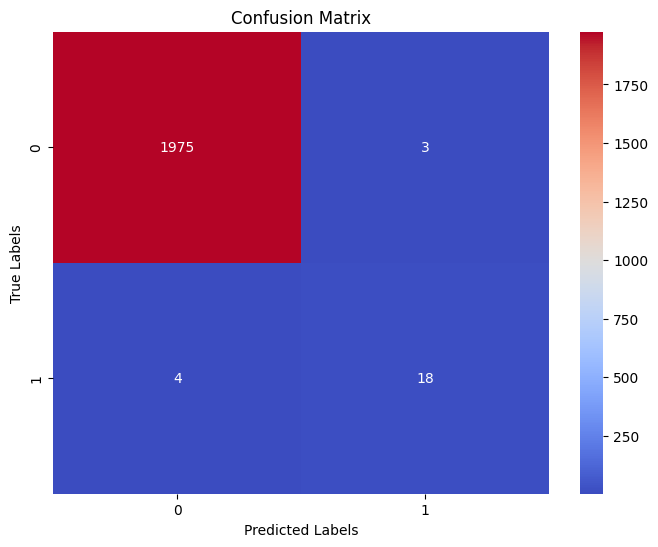

In [ ]:
confusion_matrix_metric = evaluate.load("confusion_matrix")
results = confusion_matrix_metric.compute(predictions = test['pred'].values.tolist(), references = test['cancelled'].values.tolist())

matrix = np.array(results['confusion_matrix'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='coolwarm')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


# **Calibration Thresholds**

In [ ]:
# Calibration Thresholds
# Use training dataset to determine appropriate pred proba cutoff for classifications. We can incorporate this cutoff to the test dataset in the next model run
X_train = train.sort_values('pred_proba_1',ascending=False)
pd.options.display.float_format = '{:.10f}'.format
num_chunks = 100

# Calculate the chunk size and split the dataframe into smaller chunks
chunk_size = len(X_train) // num_chunks
chunks =  [ X_train.iloc[i:i+chunk_size,:] for i in range(0, len( X_train), chunk_size)]

chunk = []
obs = []
score_range = []
events_count = []
pct_events = []

# Calculate values from each chunk
for i in range(0,num_chunks):
    # Perform your calculations on the chunk
    chunk.append(i)
    obs.append(len(chunks[i]))
    score_min = np.min(chunks[i]['pred_proba_1'])
    score_range.append(score_min)
    chunks[i]['cancelled'] = chunks[i]['cancelled'].astype(float)
    events = np.sum(chunks[i]['cancelled'])
    events_count.append(events)
    pct_events.append(events/len(chunks[i]))

/tmp/ipython-input-2933813077.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunks[i]['cancelled'] = chunks[i]['cancelled'].astype(float)
/tmp/ipython-input-2933813077.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chunks[i]['cancelled'] = chunks[i]['cancelled'].astype(float)
/tmp/ipython-input-2933813077.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation

In [ ]:
chunk_properties = pd.DataFrame({'chunk': chunk, 'observations': obs, 'score_min': score_range, 'count of cancellations': events_count, 'cancellation rate': pct_events})

In [ ]:
chunk_properties

,chunk,observations,score_min,count of cancellations,cancellation rate
0,0,30,0.9978732467,30.0000000000,1.0000000000
1,1,30,0.0083093364,10.0000000000,0.3333333333
2,2,30,0.0044561783,0.0000000000,0.0000000000
3,3,30,0.0032408487,0.0000000000,0.0000000000
4,4,30,0.0024649506,0.0000000000,0.0000000000
5,5,30,0.0021544602,0.0000000000,0.0000000000
6,6,30,0.0018646443,0.0000000000,0.0000000000
7,7,30,0.0017120480,0.0000000000,0.0000000000
8,8,30,0.0015691797,0.0000000000,0.0000000000
9,9,30,0.0014232135,0.0000000000,0.0000000000


# **Going Deeper: Misclassification Analysis**

In [ ]:
misclass = test[(test['cancelled'] == 1) & (test['pred'] == 0)]
misclass

,year,quarter,month,day_of_month,day_of_week,scheduled_hour_of_departure,scheduled_hour_of_arrival,fl_date_dt,op_unique_carrier,origin,dest,dep_delay,dep_delay_new,dep_del15,dep_delay_group,taxi_in,cancelled,crs_elapsed_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,late_aircraft_delay,ind_is_holiday,ind_is_near_holiday_down,ind_is_near_holiday_up,ind_is_near_holiday,days_until_holiday,days_since_last_holiday,ind_is_summer,ind_late_scheduled_hour_of_departure,ind_late_scheduled_hour_of_arrival,ind_early_departure,ind_dest_TX_long_dist,pred,pred_proba_0,pred_proba_1
184714,2024,2,6,10,1,6,12,2024-06-10,AS,SEA,DFW,-9.0000000000,0.0000000000,0.0000000000,-1.0000000000,NaN,1.0000000000,241.0000000000,1.0000000000,1660.0000000000,7,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,9,161,1,0,0,1,1,0,0.9982877970,0.0017121923
198071,2024,2,6,10,1,21,23,2024-06-10,WN,SAN,PHX,1.0000000000,1.0000000000,0.0000000000,0.0000000000,NaN,1.0000000000,80.0000000000,1.0000000000,304.0000000000,2,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,9,161,1,1,1,0,0,0,0.9983474016,0.0016525723
119020,2024,2,6,6,4,15,16,2024-06-06,YX,LGA,MVY,28.0000000000,28.0000000000,1.0000000000,1.0000000000,NaN,1.0000000000,80.0000000000,1.0000000000,175.0000000000,1,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,13,157,1,0,0,0,0,0,0.9994103909,0.0005896358
231449,2024,2,6,12,3,7,9,2024-06-12,NK,FLL,AUS,-3.0000000000,0.0000000000,0.0000000000,-1.0000000000,NaN,1.0000000000,185.0000000000,1.0000000000,1105.0000000000,5,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,7,163,1,0,0,1,1,0,0.9998477101,0.0001522789


In [ ]:
unique_index_values = misclass.index.unique().tolist()
misclass_orig = df2.iloc[unique_index_values]
misclass_orig

,year,quarter,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_airline_id,op_carrier,tail_num,op_carrier_fl_num,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin,origin_city_name,origin_state_abr,origin_state_fips,origin_state_nm,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest,dest_city_name,dest_state_abr,dest_state_fips,dest_state_nm,dest_wac,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,dep_delay_group,dep_time_blk,taxi_out,wheels_off,wheels_on,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,arr_delay_group,arr_time_blk,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,first_dep_time,total_add_gtime,longest_add_gtime,div_airport_landings,div_reached_dest,div_actual_elapsed_time,div_arr_delay,div_distance,div1_airport,div1_airport_id,div1_airport_seq_id,div1_wheels_on,div1_total_gtime,div1_longest_gtime,div1_wheels_off,div1_tail_num,div2_airport,div2_airport_id,div2_airport_seq_id,div2_wheels_on,div2_total_gtime,div2_longest_gtime,div2_wheels_off,div2_tail_num,div3_airport,div3_airport_id,div3_airport_seq_id,div3_wheels_on,div3_total_gtime,div3_longest_gtime,div3_wheels_off,div3_tail_num,div4_airport,div4_airport_id,div4_airport_seq_id,div4_wheels_on,div4_total_gtime,div4_longest_gtime,div4_wheels_off,div4_tail_num,div5_airport,div5_airport_id,div5_airport_seq_id,div5_wheels_on,div5_total_gtime,div5_longest_gtime,div5_wheels_off,div5_tail_num,state,city,airport,locid,owner-\nship,svc lvl\n(fy25),hub\n(fy25),role\n(fy25),enplaned\n(cy23/fy25),based aircraft\n(fy25),development\nestimate\n2025-2029
184714,2024,2,6,10,1,6/10/2024 12:00:00 AM,AS,19930,AS,N933AK,417,14747,1474703,30559,SEA,"Seattle, WA",WA,53,Washington,93,11298,1129806,30194,DFW,"Dallas/Fort Worth, TX",TX,48,Texas,74,602,553.0000000000,-9.0000000000,0.0000000000,0.0000000000,-1.0000000000,0600-0659,NaN,NaN,NaN,NaN,1203,NaN,NaN,NaN,NaN,NaN,1200-1259,1.0000000000,A,0.0000000000,241.0000000000,NaN,NaN,1.0000000000,1660.0000000000,7,NaN,NaN,NaN,NaN,NaN,553.0000000000,36.0000000000,36.0000000000,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Washington,Seattle,Seattle-Tacoma International,SEA,PU,P,L,NaN,24594202.0000000000,3.0000000000,539206029.0000000000
198071,2024,2,6,10,1,6/10/2024 12:00:00 AM,WN,19393,WN,N7822A,3181,14679,1467903,33570,SAN,"San Diego, CA",CA,6,California,91,14107,1410702,30466,PHX,"Phoenix, AZ",AZ,4,Arizona,81,2140,2141.0000000000,1.0000000000,1.0000000000,0.0000000000,0.0000000000,2100-2159,NaN,NaN,NaN,NaN,2300,NaN,NaN,NaN,NaN,NaN,2300-2359,1.0000000000,A,0.0000000000,80.0000000000,NaN,NaN,1.0000000000,304.0000000000,2,NaN,NaN,NaN,NaN,NaN,2141.0000000000,20.0000000000,20.0000000000,0,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,California,San Diego,San Diego International,SAN,PU,P,L,NaN,12190166.0000000000,10.0000000000,2405797784.0000000000
119020,2024,2,6,6,4,6/6/2024 12:00:00 AM,YX,20452,YX,N229JQ,5686,12953,1295304,31703,LGA,"New York, NY",NY,36,New York,22,13541,1354102,33541,MVY,"Martha's Vineyard, MA",MA,25,Massachusetts,13,1515,1543.0000000000,28.0000000000,28.0000000000,1.0000000000,1.0000000000,1500-1559,43.0000000000,1626.0000000000,NaN,NaN,1635,NaN,NaN,NaN,NaN,NaN,1600-1659,1.0000000000,B,0.0000000000,80.0000000000,NaN,NaN,1.0000000000,175.0000000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,NaN,NaN,NaN,LGA,12953.0000000000,1295304.0000000000,1754.0000000000,17.0000000000,17.0000000000,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New York,New York,Laguard

# **Feature Importance Plots**

In [ ]:
# how each feature in the original unaltered dataset affected the model outcomes
predictor.feature_importance(df.head(1000))

These features in provided data are not utilized by the predictor and will be ignored: ['year', 'quarter', 'month', 'flights', 'ind_is_summer']
Loading: /content/AutogluonModels/ag-20251204_033322/models/WeightedEnsemble_L2/model.pkl
Computing feature importance via permutation shuffling for 30 features using 1000 rows with 5 shuffle sets...
Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Loading: /content/AutogluonModels/ag-20251204_033322/models/WeightedEnsemble_L2/model.pkl
	2853.66s	= Expected runtime (570.73s per shuffle set)
Loading: /content/AutogluonModels/ag-20251204_033322/models/TabPFNMix/model.pkl
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but

,importance,stddev,p_value,n,p99_high,p99_low
dep_del15,0.4224466463,0.0325522847,0.0000041975,5,0.4894722505,0.3554210422
weather_delay,0.0617505081,0.0195420861,0.0010583395,5,0.1019879334,0.0215130828
dep_delay_new,0.0236026423,0.0096905083,0.0027600445,5,0.0435555327,0.0036497518
dep_delay,0.0229166667,0.0060850434,0.0005443366,5,0.0354458551,0.0103874783
dep_delay_group,0.0208587398,0.0107043838,0.0060441293,5,0.0428992141,-0.0011817345
ind_dest_TX_long_dist,0.0184197154,0.0001270325,0.0000000003,5,0.0186812772,0.0181581537
fl_date_dt,0.0083206301,0.0097353044,0.0642887191,5,0.0283657565,-0.0117244963
ind_early_departure,0.0080665650,0.0049966349,0.0112792347,5,0.0183547053,-0.0022215753
scheduled_hour_of_arrival,0.0067200203,0.0037634121,0.0081137511,5,0.0144689379,-0.0010288972
late_aircraft_delay,0.0062881098,0.0048590977,0.0221994310,5,0.0162930591,-0.0037168395


# **Finalize model for production**

In [ ]:
# save the model object
predictor.save("./AutogluonModels/flight_cancellation_model")

Saving /content/AutogluonModels/ag-20251204_033322/models/trainer.pkl
Saving /content/AutogluonModels/ag-20251204_033322/learner.pkl
Saving /content/AutogluonModels/ag-20251204_033322/predictor.pkl


In [ ]:
test.head()

,year,quarter,month,day_of_month,day_of_week,scheduled_hour_of_departure,scheduled_hour_of_arrival,fl_date_dt,op_unique_carrier,origin,dest,dep_delay,dep_delay_new,dep_del15,dep_delay_group,taxi_in,cancelled,crs_elapsed_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,late_aircraft_delay,ind_is_holiday,ind_is_near_holiday_down,ind_is_near_holiday_up,ind_is_near_holiday,days_until_holiday,days_since_last_holiday,ind_is_summer,ind_late_scheduled_hour_of_departure,ind_late_scheduled_hour_of_arrival,ind_early_departure,ind_dest_TX_long_dist,pred,pred_proba_0,pred_proba_1
48841,2024,2,6,3,1,15,16,2024-06-03,NK,BUR,LAS,-10.0000000000,0.0000000000,0.0000000000,-1.0000000000,4.0000000000,0.0000000000,74.0000000000,1.0000000000,223.0000000000,1,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,16,154,1,0,0,1,0,0,0.9996831417,0.0003168848
550096,2024,2,6,27,4,14,16,2024-06-27,YX,LGA,TYS,25.0000000000,25.0000000000,1.0000000000,1.0000000000,9.0000000000,0.0000000000,141.0000000000,1.0000000000,647.0000000000,3,25.0000000000,0.0000000000,6.0000000000,0.0000000000,0.0000000000,False,False,0.0000000000,7,178,1,0,0,0,0,0,0.9987348318,0.0012651696
309333,2024,2,6,16,7,11,13,2024-06-16,DL,AUS,MSP,5.0000000000,5.0000000000,0.0000000000,0.0000000000,2.0000000000,0.0000000000,168.0000000000,1.0000000000,1042.0000000000,5,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,3,167,1,0,0,0,0,0,0.9995043278,0.0004956983
83710,2024,2,6,5,3,5,7,2024-06-05,DL,PVD,DTW,6.0000000000,6.0000000000,0.0000000000,0.0000000000,8.0000000000,0.0000000000,123.0000000000,1.0000000000,615.0000000000,3,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,14,156,1,0,0,0,0,0,0.9999166131,0.0000834134
26253,2024,2,6,2,7,11,14,2024-06-02,F9,LAS,DEN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,30.0000000000,0.0000000000,132.0000000000,1.0000000000,628.0000000000,3,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,17,153,1,0,0,0,0,0,0.9998753071,0.0001246718


In [ ]:
# Only keep features present in original df
test = test[df.columns.tolist()]
test.head()  # confirm the extra cols were dropped

,year,quarter,month,day_of_month,day_of_week,scheduled_hour_of_departure,scheduled_hour_of_arrival,fl_date_dt,op_unique_carrier,origin,dest,dep_delay,dep_delay_new,dep_del15,dep_delay_group,taxi_in,cancelled,crs_elapsed_time,flights,distance,distance_group,carrier_delay,weather_delay,nas_delay,late_aircraft_delay,ind_is_holiday,ind_is_near_holiday_down,ind_is_near_holiday_up,ind_is_near_holiday,days_until_holiday,days_since_last_holiday,ind_is_summer,ind_late_scheduled_hour_of_departure,ind_late_scheduled_hour_of_arrival,ind_early_departure,ind_dest_TX_long_dist
48841,2024,2,6,3,1,15,16,2024-06-03,NK,BUR,LAS,-10.0000000000,0.0000000000,0.0000000000,-1.0000000000,4.0000000000,0.0000000000,74.0000000000,1.0000000000,223.0000000000,1,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,16,154,1,0,0,1,0
550096,2024,2,6,27,4,14,16,2024-06-27,YX,LGA,TYS,25.0000000000,25.0000000000,1.0000000000,1.0000000000,9.0000000000,0.0000000000,141.0000000000,1.0000000000,647.0000000000,3,25.0000000000,0.0000000000,6.0000000000,0.0000000000,0.0000000000,False,False,0.0000000000,7,178,1,0,0,0,0
309333,2024,2,6,16,7,11,13,2024-06-16,DL,AUS,MSP,5.0000000000,5.0000000000,0.0000000000,0.0000000000,2.0000000000,0.0000000000,168.0000000000,1.0000000000,1042.0000000000,5,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,3,167,1,0,0,0,0
83710,2024,2,6,5,3,5,7,2024-06-05,DL,PVD,DTW,6.0000000000,6.0000000000,0.0000000000,0.0000000000,8.0000000000,0.0000000000,123.0000000000,1.0000000000,615.0000000000,3,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,14,156,1,0,0,0,0
26253,2024,2,6,2,7,11,14,2024-06-02,F9,LAS,DEN,0.0000000000,0.0000000000,0.0000000000,0.0000000000,30.0000000000,0.0000000000,132.0000000000,1.0000000000,628.0000000000,3,NaN,NaN,NaN,NaN,0.0000000000,False,False,0.0000000000,17,153,1,0,0,0,0


In [1]:
# Test model object
# load the saved model
saved_model = TabularPredictor.load("./AutogluonModels/ag-20251117_043540") # replace with your file path

# Make predictions using saved model
test['pred'] = saved_model.predict(test,model=chosen_model)

test['pred_proba_0'] = saved_model.predict_proba(test,model=chosen_model)[0]
test['pred_proba_1'] = saved_model.predict_proba(test,model=chosen_model)[1]
# # # edit decision threshold
thres = 0.02
test['pred'] = np.where(test['pred_proba_1'] > thres, 1, 0)

In [ ]:
test.head()